Files originally from https://github.com/LucasSilvaFerreira/Perturb_Loader


In [1]:
import mudata as md
import anndata as ad
import numpy as np
import pandas as pd
import perturbvi
import seaborn as sns
import scanpy as sc
import os
import scipy
import pyro
from scipy.stats import norm
import matplotlib.pyplot as plt
import torch

smoke_test = True
subsample_frac = 1.
downsample_frac = 1.

# selected_guides = ["ACTG1_TSS|1", "ACTG1_TSS|2", "ACTB_TSS|1", "ACTB_TSS|2"]
# selected_genes = ["ACTG1"]
# selected_guides = ["TMED10_TSS|1", "TMED10_TSS|2"]
# selected_genes = ["TMED10"]
# selected_guides = ["KRT18_TSS|1", "KRT18_TSS|2"]
selected_genes = ["KRT18"]
data_dir = "../../../Data/gasperini_pilot"


/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Global seed set to 0


In [2]:
# load sceptre list of genes/guides


In [3]:
sceptre_df = pd.read_csv(f"{data_dir}/sceptre_results-2023_01_13.csv")
sceptre_df = sceptre_df.rename(columns={"gRNA_id": "guide", "gene_id": "gene", "z_value":"SCEPTRE_z_value","p_value":"SCEPTRE_p_value"})
if not smoke_test:
    selected_genes = sceptre_df["gene"].unique()
selected_guides = sceptre_df["guide"].unique()

print(len(selected_genes), len(selected_guides))
# sceptre_df.query("guide=='GATA2_TSS|1'")


1 1243


In [4]:
def construct_mudata(data_dir="."):
    rna_adata = ad.read_h5ad(f"{data_dir}/ann_exp.h5ad")
    rna_adata.obs["library_size"] = rna_adata.X.sum(axis=1)
    # rna_adata.obs["size_factor"] = rna_adata.obs["library_size"]
    rna_adata.varm["element_tested"] = ad.read_h5ad(f"{data_dir}/ann_Element_x_tested_genes.h5ad").to_df().T
    # sc.pp.filter_genes(rna_adata, min_cells=len(rna_adata)*0.1) # need genes where at least 10% of cells with nonzero counts
    grna_adata = ad.read_h5ad(f"{data_dir}/ann_guide.h5ad")
    grna_adata.varm["element_targeted"] = ad.read_h5ad(f"{data_dir}/ann_Element_guide.h5ad").to_df().T
    assert (rna_adata.varm["element_tested"].columns == grna_adata.varm["element_targeted"].columns).all()
    mdata = md.MuData({"rna": rna_adata, "grna": grna_adata})
    return mdata


force = True
mudata_file = "gasperini_pilot_highMOI.h5mu"
if mudata_file not in os.listdir(data_dir) or force:
    mdata = construct_mudata(data_dir)
else:
    mdata = md.read_h5mu(os.path.join(data_dir, mudata_file))

# mdata.raw=mdata.copy()
total_umis = mdata.mod['rna'].X.sum()
print('total depth', total_umis/1e6, 'million UMI counts')

# downsample UMIS (w/ replacement)
# counts_tensor=torch.tensor(mdata.mod['rna'].X.todense(), dtype=torch.int64)
# counts_sampler=torch.distributions.Binomial(counts_tensor, probs=torch.tensor(downsample_frac))
# counts_sampled=counts_sampler.sample((1,))
# mdata['rna'].X =scipy.sparse.csr_array(counts_sampled[0, ...].cpu().numpy())
# # mdata['rna'].X = scipy.sparse.csr_matrix(counts_sampled)
# downsample_umis = int(mdata['rna'].X.sum())
# print('subsampled depth', downsample_umis/1e6, 'million UMI counts', )
# mdata.update()

total depth 717.674112 million UMI counts


In [5]:
# guides = mdata["grna"].var_names
# # selected_guides = list(guides[guides.str.contains(r"TSS|random|scrambled", regex=True)])

# elements = list({guide.split("|")[0] for guide in selected_guides})
# selected_elements = [e for e in elements if e in mdata["grna"].varm["element_targeted"].columns]
# element_subset = mdata["grna"].varm["element_targeted"][selected_elements].copy()

# grna_subset = mdata["grna"]
# grna_subset.varm["element_targeted"] = element_subset

# grna_subset = mdata["grna"][:, selected_guides]
# # genes = list(sorted({e.split("_")[0] for e in selected_elements if "_TSS" in e}))
# # subset_genes = [g for g in genes if g in mdata["rna"].var_names]
# # print(selected_genes)

# if smoke_test:
#     selected_genes = [test_gene]  # DANGER SINGLE GENE ONLY
# assert grna_subset.varm["element_targeted"].shape == (len(selected_guides), len(selected_elements))
mdata.mod['grna'] = mdata.mod['grna'][:,selected_guides]
mdata.mod['rna'] = mdata.mod['rna'][:,selected_genes]
mdata.mod['rna'].X.sum()

166142.0

In [6]:
guide_obs = mdata["grna"][:, selected_guides].X.sum(axis=1).copy().astype(bool)
guide_obs_idx = np.where(guide_obs)[0]
discard_cells = np.random.choice(guide_obs_idx, size=int(guide_obs.sum()*(1-subsample_frac)), replace=False)
subset_idx = [i for i in range(len(mdata)) if i not in discard_cells]
print("discarded", len(discard_cells), "cells with guide")
mdata.update()
mdata=mdata[subset_idx,:].copy()
mdata
# mdata.mod['rna']
# rna_downsample = sc.pp.downsample_counts(mdata.mod['rna'], total_counts = 1e8)


discarded 0 cells with guide


MuData object with n_obs × n_vars = 47964 × 1244
  2 modalities
    rna:	47964 x 1
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 1243
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [7]:
mdata["rna"].obs['percent_mito']

AAACCTGAGCGAGAAA    0.035365
AAACCTGAGCTGTCTA    0.027356
AAACCTGAGTTATCGC    0.049800
AAACCTGAGTTCCACA    0.032975
AAACCTGCAAATACAG    0.022816
                      ...   
TTTGTCAGTGTTTGTG    0.044018
TTTGTCATCACAAACC    0.042441
TTTGTCATCAGAGGTG    0.034075
TTTGTCATCGCGATCG    0.036911
TTTGTCATCTGGCGTG    0.046777
Name: percent_mito, Length: 47964, dtype: float32

In [8]:
# rna_subset = mdata["rna"]
# rna_subset.varm["element_tested"] = rna_subset.varm["element_tested"][selected_elements].copy()
# rna_subset = rna_subset[:, selected_genes]
# mdata_subset = md.MuData({"rna": rna_subset.copy(), "grna": grna_subset.copy()})
# assert (
#     mdata_subset["rna"].varm["element_tested"].columns == mdata_subset["grna"].varm["element_targeted"].columns
# ).all()
# mdata_subset


In [9]:
perturbvi.PERTURBVI.setup_mudata(
    mdata,
    batch_key="bath_number",
    library_size_key="library_size",
    # size_factor_key="library_size",
    var_by_element_key="element_tested",
    perturb_by_element_key="element_targeted",
    continuous_covariates_keys=["percent_mito"],
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbvi.PERTURBVI(mdata, fit_lib_size=True)
model.view_anndata_setup()


INFO     Using column names from columns of adata.varm['element_tested']                                           
INFO     Using column names from columns of adata.varm['element_targeted']                                         


Anndata setup with scvi-tools version 0.20.1.

Setup via `PERTURBVI.setup_anndata` with arguments:

{
│   'rna_layer': None,
│   'perturbation_layer': None,
│   'batch_key': 'bath_number',
│   'var_by_element_key': 'element_tested',
│   'perturb_by_element_key': 'element_targeted',
│   'library_size_key': 'library_size',
│   'size_factor_key': None,
│   'continuous_covariates_keys': ['percent_mito'],
│   'modalities': {'rna_layer': 'rna', 'perturbation_layer': 'grna'}
}

        Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch         │   6   │
│         n_cells         │ 47964 │
│ n_extra_continuous_covs │   1   │
│     n_perturbations     │ 1243  │
│   n_targeted_elements   │ 1561  │
│    n_tested_elements    │ 1561  │
│         n_vars          │   1   │
└─────────────────────────┴───────┘

                                 Data Registry                                  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃                 scvi-tools Location                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.mod['rna'].X                  │
│         batch         │         adata.mod['rna'].obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.mod['rna'].obsm['_scvi_extra_continuous_covs'] │
│         ind_x         │            adata.mod['rna'].obs['_ind_x']            │
│     perturbations     │                 adata.mod['grna'].X                  │
│      size_factor      │         adata.mod['rna'].obs['_size_factor']         │
│   targeted_elements   │      adata.mod['grna'].varm['element_targeted']      │
│    tested_elements    │       adata.mod['rna'].varm['element_tested']        │
└───────────────────────┴──────────────────────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['bath_number'] │     1      │          0          │
│                          │     2      │          1          │
│                          │     3      │          2          │
│                          │     4      │          3          │
│                          │     5      │          4          │
│                          │     6      │          5          │
└──────────────────────────┴────────────┴─────────────────────┘

 extra_continuous_covs State 
          Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['percent_mito'] │
└───────────────────────────┘

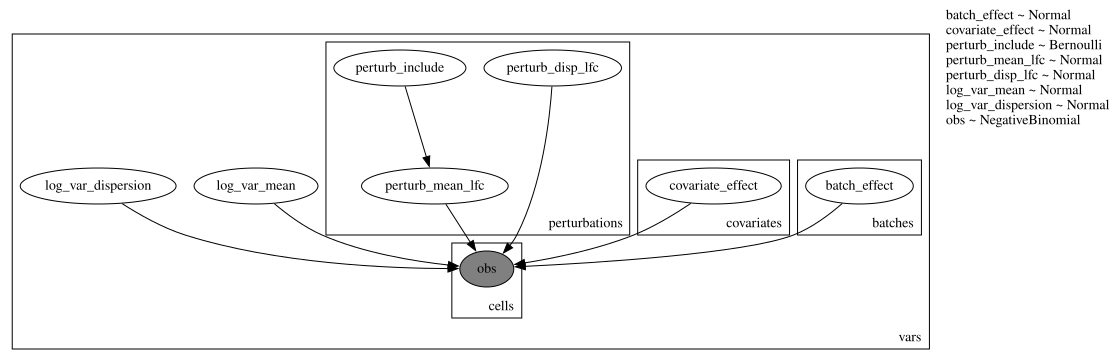

In [10]:
# requires graphviz to be installed
model.render_model()

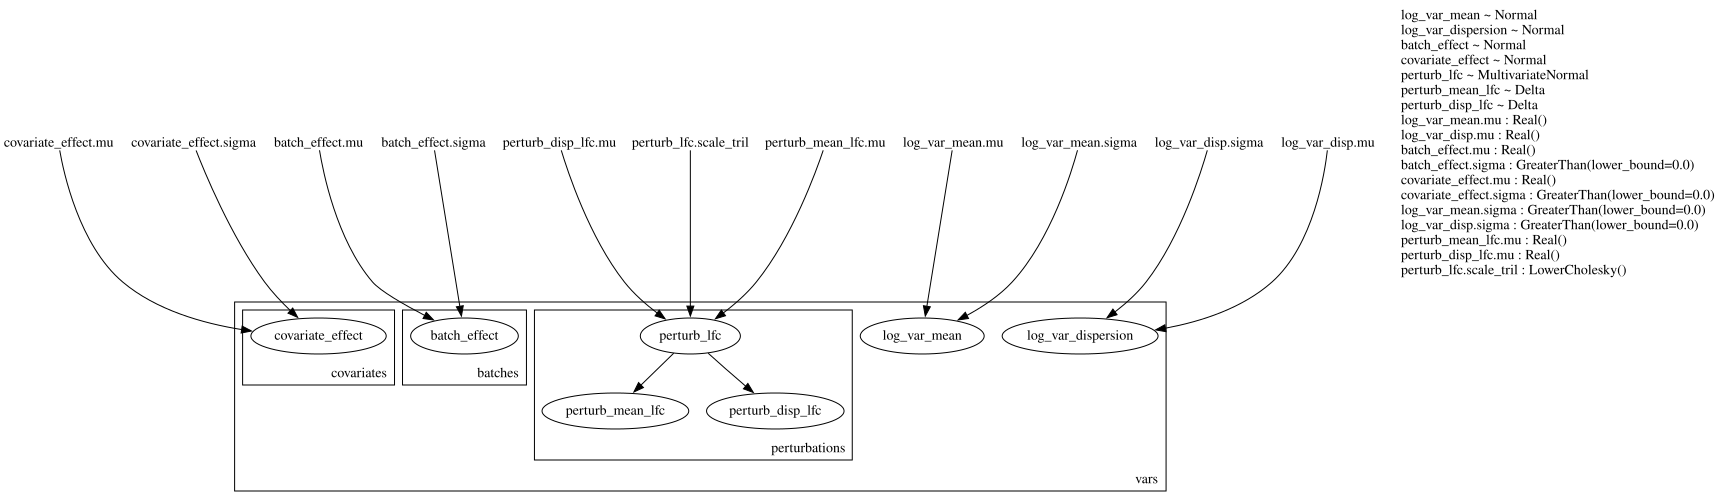

In [11]:
model.render_guide()

## Model training

We can start out with a really high learning rate, then decrease the learning rate to fine-tune


In [12]:
# burn-in
if smoke_test:
    model.train(10, lr=0.1, batch_size=1024)
else:
    model.train(10, lr=0.1, batch_size=4096)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 10/10: 100%|██████████| 10/10 [00:06<00:00,  1.63it/s, v_num=1, elbo_train=1.25e+5]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|██████████| 10/10 [00:06<00:00,  1.62it/s, v_num=1, elbo_train=1.25e+5]


In [13]:
# fine-tuning
model.train(50, lr=0.01, batch_size=8192)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/trainer.py:1609: PossibleUserWarning: The number of training batches (6) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower 

Epoch 50/50: 100%|██████████| 50/50 [00:08<00:00,  5.46it/s, v_num=1, elbo_train=1.16e+5]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [00:08<00:00,  5.61it/s, v_num=1, elbo_train=1.16e+5]


In [14]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)
    if sum(v.shape) <= 1:
        print(v)


log_var_mean.mu torch.Size([1])
tensor([-2.4309], requires_grad=True)
log_var_disp.mu torch.Size([1])
tensor([1.2877], requires_grad=True)
batch_effect.mu torch.Size([6, 1])
batch_effect.sigma torch.Size([6, 1])
covariate_effect.mu torch.Size([2, 1])
covariate_effect.sigma torch.Size([2, 1])
log_var_mean.sigma torch.Size([1])
tensor([0.0094], grad_fn=<AddBackward0>)
log_var_disp.sigma torch.Size([1])
tensor([0.0210], grad_fn=<AddBackward0>)
perturb_mean_lfc.mu torch.Size([1243, 1])
perturb_disp_lfc.mu torch.Size([1243, 1])
perturb_lfc.scale_tril torch.Size([1243, 1, 2, 2])


In [15]:
print(pyro.get_param_store()['covariate_effect.mu'])
print(pyro.get_param_store()['covariate_effect.sigma'])


tensor([[-8.9918],
        [-0.3551]], requires_grad=True)
tensor([[0.0585],
        [0.0018]], grad_fn=<AddBackward0>)


In [16]:
# plt.hist(pyro.get_param_store()["library_size_effect.mu"].cpu().detach().numpy())


In [17]:
%load_ext autoreload
%autoreload 2

# lfc_threshold = -0.1 # ~ at least 10% upreg
lfc_threshold = 0 # nonzero knockdown
# gene_index=45

# scale_factor = 0.01
perturb_mean_lfc_mu = pyro.get_param_store()['perturb_mean_lfc.mu'].detach().cpu().numpy()
perturb_disp_lfc_mu = pyro.get_param_store()['perturb_disp_lfc.mu'].detach().cpu().numpy()
lfc_cov_tril = pyro.get_param_store()['perturb_lfc.scale_tril']
lfc_cov = lfc_cov_tril @ lfc_cov_tril.transpose(dim0=-1, dim1=-2)
perturb_mean_lfc_sigma = lfc_cov[...,0,0].sqrt().detach().cpu().numpy()
perturb_disp_lfc_sigma = lfc_cov[...,1,1].sqrt().detach().cpu().numpy()
assert perturb_mean_lfc_mu.shape == perturb_mean_lfc_sigma.shape
perturb_z_scores = perturb_mean_lfc_mu/perturb_mean_lfc_sigma
perturb_p_vals = norm.sf(lfc_threshold, loc=perturb_mean_lfc_mu, scale=perturb_mean_lfc_sigma)

def make_long_df(mat, value_name):
    return (
        pd.DataFrame(data=mat, columns=selected_genes, index=selected_guides)
        .melt(var_name="gene", value_name=value_name, ignore_index=False)
        .reset_index(names="guide")
        .assign(is_target=lambda x: x['guide'].str.split('_', expand=True)[0]==x['gene'])
    )
mu_df = make_long_df(perturb_mean_lfc_mu, "mu")
z_df = make_long_df(perturb_z_scores, "z_value")
p_df = make_long_df(perturb_p_vals, "p_value")


In [18]:

scpower_df = pd.merge(z_df, p_df)
if not smoke_test:
    scpower_df.to_csv("~/Downloads/all_results.csv")
# significant_results = scpower_df.query("p_value < 1e-8")
# significant_results['element'] = significant_results['guide'].str.split("|", expand=True)[0]
# significant_results
scpower_df.sort_values("p_value")

# guide_gene_pairs = significant_results.groupby(['element','gene'])['guide'].count()
# guide_gene_pairs=guide_gene_pairs[guide_gene_pairs==2]
# guide_gene_pairs.to_excel("~/Downloads/guide_pairs.xlsx")
# # guide_gene_pairs.index
# scpower_df.query("p_value < 1e-3").to_excel("~/Downloads/significant_results.xlsx")
# significant_results['guide'].str.split("_", expand=True)[0]
# significant_results.head(1000).to_excel("~/Downloads/significant_results.xlsx")

,guide,gene,z_value,is_target,p_value
278,KRT18_TSS|1,KRT18,-22.026762,True,7.979059e-108
279,KRT18_TSS|2,KRT18,-17.742544,True,9.840918e-71
138,DDX3X_TSS|1,KRT18,-9.676197,False,1.903055e-22
159,EEF2_TSS|2,KRT18,-4.824979,False,7.000907e-07
1010,chr12:53267628-53267651|1,KRT18,-4.524384,False,3.028590e-06
...,...,...,...,...,...
860,chr11:33963092-33963115|2,KRT18,4.760541,False,9.999990e-01
500,RABGGTB_TSS|2,KRT18,5.180352,False,9.999999e-01
593,SMS_TSS|2,KRT18,5.687160,False,1.000000e+00
861,chr11:33966182-33966205|1,KRT18,5.706958,False,1.000000e+00


In [40]:
model.get_discrete_model()

tensor([[2.]])

In [20]:
print(scpower_df)

              guide   gene   z_value  is_target   p_value
0        ACTB_TSS|1  KRT18  0.221487      False  0.587643
1        ACTB_TSS|2  KRT18 -1.002885      False  0.157958
2       ACTG1_TSS|1  KRT18  0.154225      False  0.561284
3       ACTG1_TSS|2  KRT18 -0.073928      False  0.470534
4       ACYP1_TSS|1  KRT18  1.060765      False  0.855602
...             ...    ...       ...        ...       ...
1238  scrambled_7|2  KRT18  0.963095      False  0.832250
1239  scrambled_8|1  KRT18  1.689667      False  0.954454
1240  scrambled_8|2  KRT18  1.091927      False  0.862567
1241  scrambled_9|1  KRT18 -0.015932      False  0.493644
1242  scrambled_9|2  KRT18 -2.550765      False  0.005374

[1243 rows x 5 columns]


[]

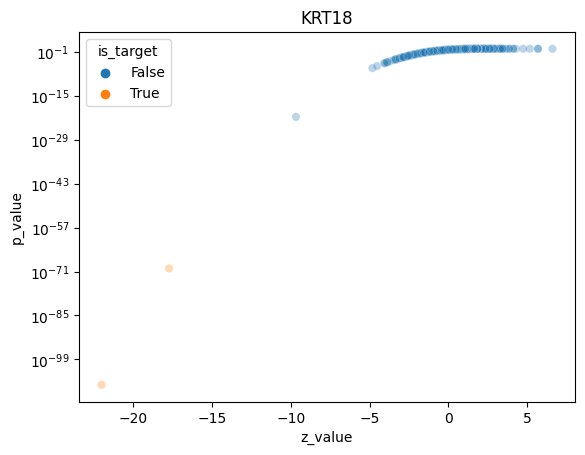

In [21]:
sns.scatterplot(
    scpower_df,
    hue="is_target",
    x="z_value",
    y="p_value",
    alpha=0.3
)
if smoke_test:
    plt.title(selected_genes[0])

plt.semilogy()
# significant_results.groupby("guide").count()['gene'].sort_values().tail(20)
# significant_results.to_excel("significant_results.xlsx")
# # perturb_z_scores[:,gene_index].detach().cpu().numpy()
# z_df = pd.DataFrame({'z_score': perturb_z_scores[:,gene_index],
#                     'mean_mu': perturb_mean_lfc_mu[:,gene_index],
#                     'disp_mu': perturb_disp_lfc_mu[:,gene_index],
#                     'mu_p_val': perturb_p_vals[:,gene_index],
#                     'grna': mdata_subset['grna'].var_names,})
# # z_df.hist('mu_p_val', bins=100)
# names[gene_index])
# print(z_df.sort_values('mu_p_val', ascending=True).reset_index(drop=True).head(20))


In [22]:
import matplotlib.pyplot as plt

# plt.scatter(pyro.get_param_store()["log_var_mean.mu"].cpu().detach().numpy(), pyro.get_param_store()["log_var_disp.mu"].cpu().detach().numpy(), alpha=0.1)


## Compare to SCEPTRE results


In [23]:
# merge_df=merge_df.assign(residual = lambda x: x['z_value']-x['value'])
# merge_df.sort_values('residual').tail(20)


[]

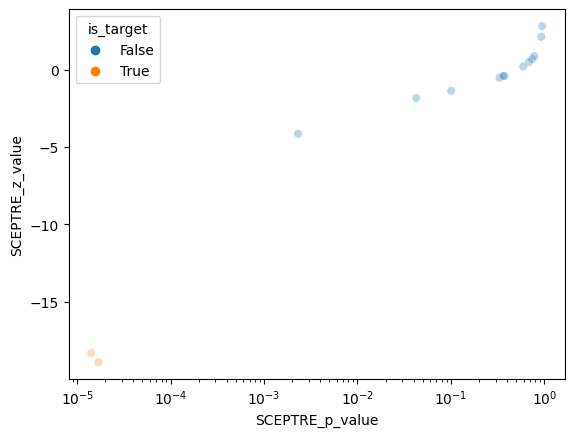

In [24]:
import matplotlib.pyplot as plt

merge_df = pd.merge(sceptre_df, scpower_df, how="inner")

sns.scatterplot(merge_df, x="SCEPTRE_p_value", y="SCEPTRE_z_value", hue="is_target", alpha=0.3)
plt.semilogx()

# plt.xlim([-40, 20])
# plt.ylim([-40, 20])

<Axes: xlabel='z_value', ylabel='SCEPTRE_z_value'>

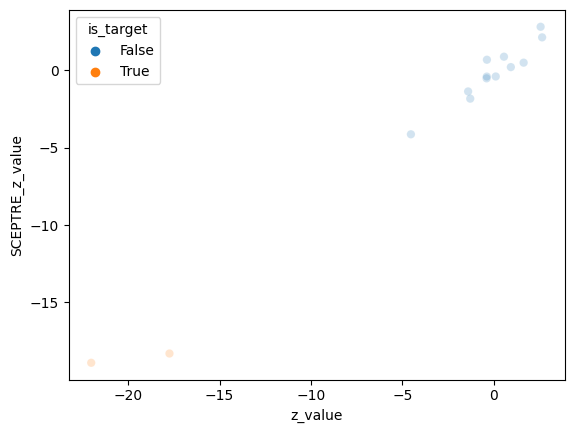

In [25]:
sns.scatterplot(merge_df, x="z_value", y="SCEPTRE_z_value", hue="is_target", alpha=0.2)


[]

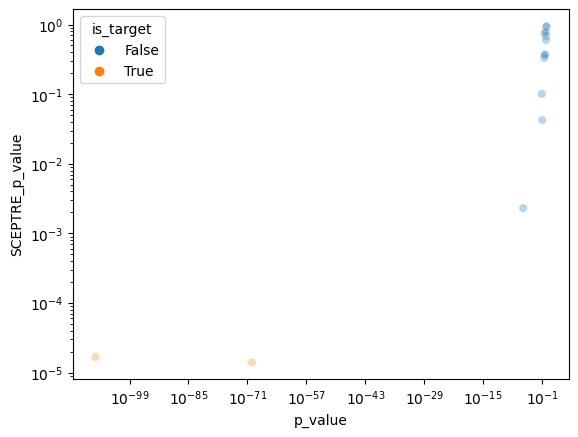

In [26]:
sns.scatterplot(merge_df, x="p_value", y="SCEPTRE_p_value", hue="is_target", alpha=0.3)
plt.loglog()
# plt.xlim(1e-20, 2)
# plt.ylim(1e-20, 2)

plot some genes


278                   KRT18_TSS|1
279                   KRT18_TSS|2
138                   DDX3X_TSS|1
159                    EEF2_TSS|2
1010    chr12:53267628-53267651|1
1045    chr13:29106285-29106308|2
588                    SMC3_TSS|1
321                    MND1_TSS|2
629                  TMED10_TSS|2
108                  COMMD3_TSS|2
Name: guide, dtype: object
KRT18 KRT18_TSS|1


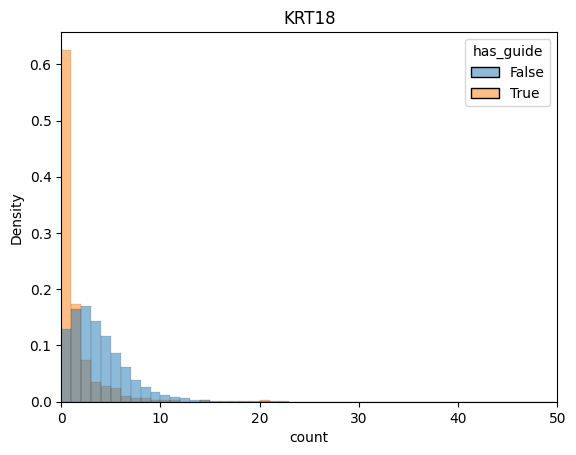

KRT18 KRT18_TSS|2


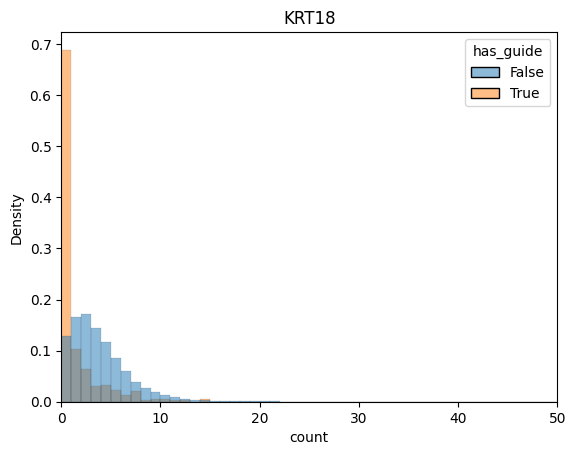

KRT18 DDX3X_TSS|1


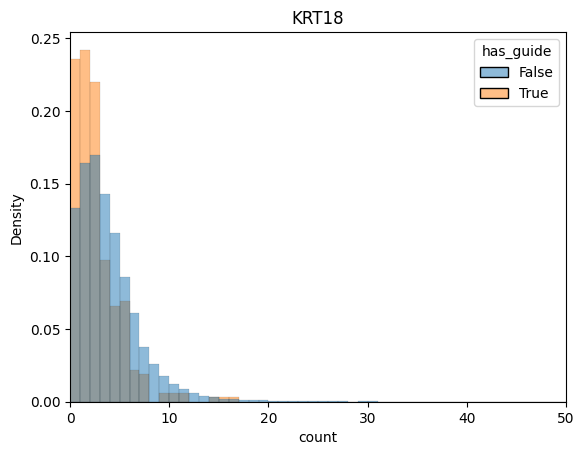

KRT18 EEF2_TSS|2


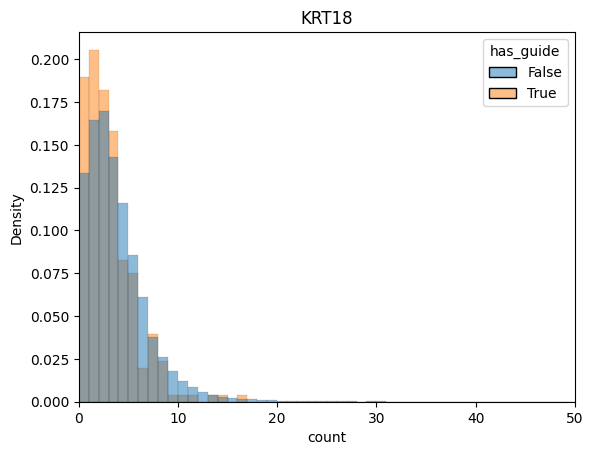

KRT18 chr12:53267628-53267651|1


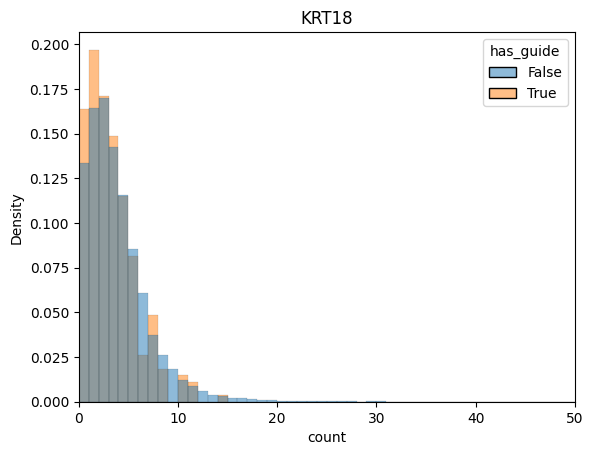

KRT18 chr13:29106285-29106308|2


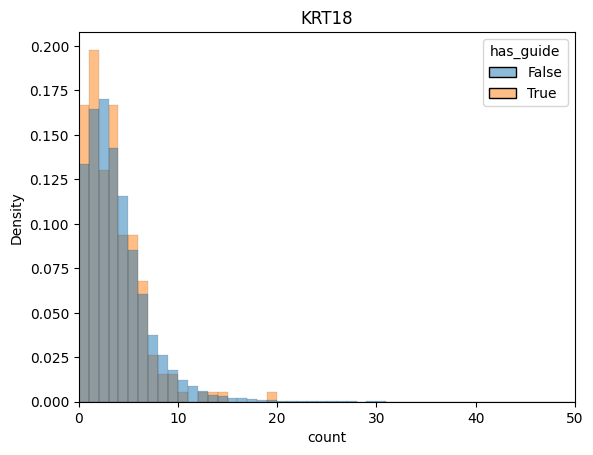

KRT18 SMC3_TSS|1


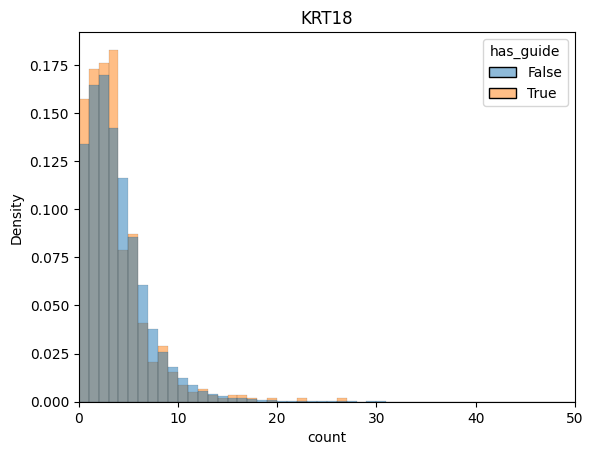

KRT18 MND1_TSS|2


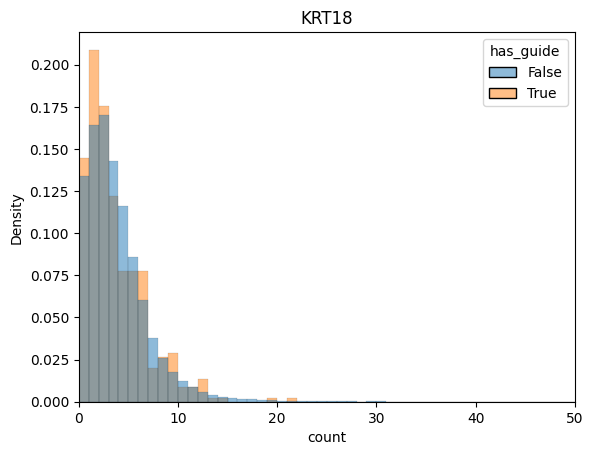

KRT18 TMED10_TSS|2


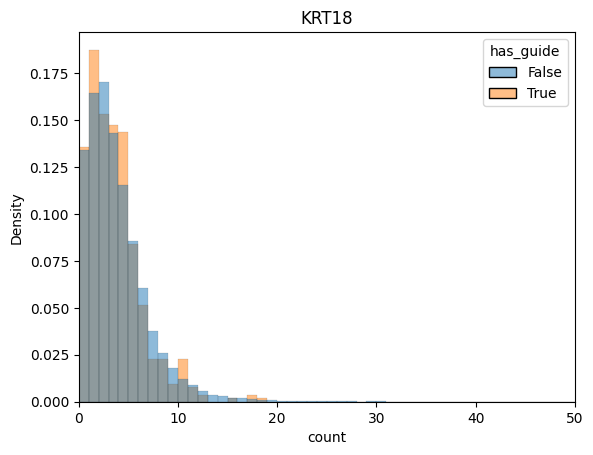

KRT18 COMMD3_TSS|2


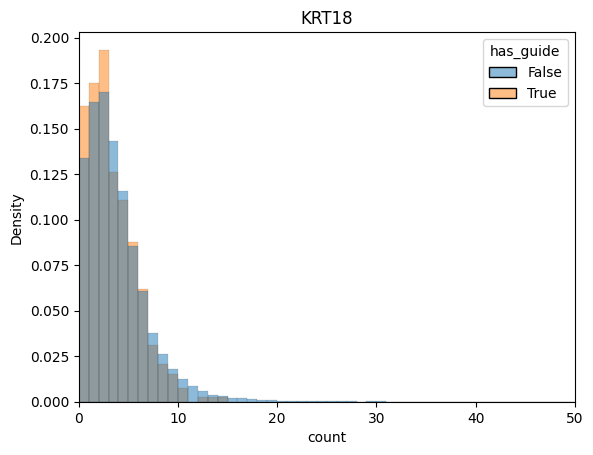

In [27]:
import scanpy as sc

# guide_1 = f"{plot_gene}_TSS|1"
# guide_2 = f"{plot_gene}_TSS|2"
# guide_1 = "TMED10_TSS|1"
# guide_2 = "TMED10_TSS|2"
plot_genes=[selected_genes[0]]
plot_guides=scpower_df.nsmallest(10, "p_value")['guide']

print(plot_guides)
# plot_genes = selected_genes
# plot_gene = selected_genes
# plot_genes = ["TMED10","KDELR2","KDELR3","SEC13", "YIF1A"]
for plot_gene in plot_genes:
    for plot_guide in plot_guides:
        print(plot_gene, plot_guide)
        counts = mdata["rna"][:, plot_gene].X.todense().A1
        guide_1_obs = mdata["grna"][:, plot_guide].X.astype(bool).squeeze()

        plot_df = pd.DataFrame({"count": counts, "has_guide": guide_1_obs})
        sns.histplot(
            plot_df,
            x="count",
            hue="has_guide",
            binwidth=1,
            common_norm=False,
            stat="density",
        )
        # plt.semilogy()
        plt.xlim(0, 50)
        plt.title(plot_gene)
        plt.show()


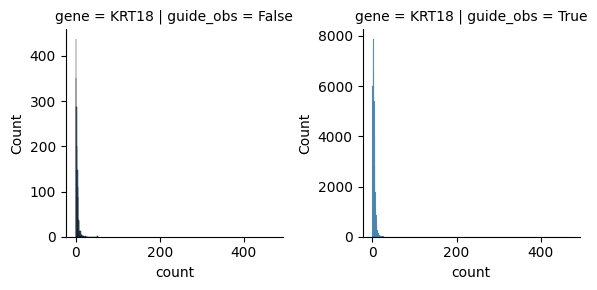

In [28]:
counts_df = mdata["rna"][:, selected_genes].to_df()
guide_obs = mdata["grna"][:, selected_guides].X.sum(axis=1).copy().astype(bool)
counts_df['guide_obs']=guide_obs


plot_df = counts_df.melt(id_vars='guide_obs',var_name='gene',value_name='count')
g = sns.FacetGrid(plot_df, row="gene", col="guide_obs",sharey=False)
g.map_dataframe(sns.histplot, x="count", binwidth=1, hue_order=[False,True])


# sns.histplot(
#     plot_df.query('has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# plt.show()
# sns.histplot(
#     plot_df.query('not has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# # plt.xlim(0, 50)
# g.title(f"gene: {plot_gene}, guide: {plot_guide}")
# plt.show()

